In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
files = [
    "ID-SG_Collab__EL_Transport.csv",
    "KH-SG_Collab__EL_Transport.csv",
    "MY-SG_Collab__EL_Transport.csv",
    "SG-VN_Collab__EL_Transport.csv"
]
dfs = list()
for file in files:
    data = pd.read_csv(file)
    data["cid"] = file.split("__")[0]
    data.rename(columns={"uid": "sid"}, inplace=True)
    data.columns = list(map(lambda s: s.lower(), data.columns.tolist()))
    data = data[["cid", "sid", "cost", "emissions", "el_transport"]]
    data = data.sort_values(by=["cid", "sid"])
    dfs.append(data)
df = pd.concat(dfs)
df.reset_index(drop=True, inplace=True)

df = df.loc[df.sid!="S-BAU"]
df.reset_index(drop=True, inplace=True)
df["sid"] = df["sid"].apply(lambda x: int(x.split("-")[-1]))

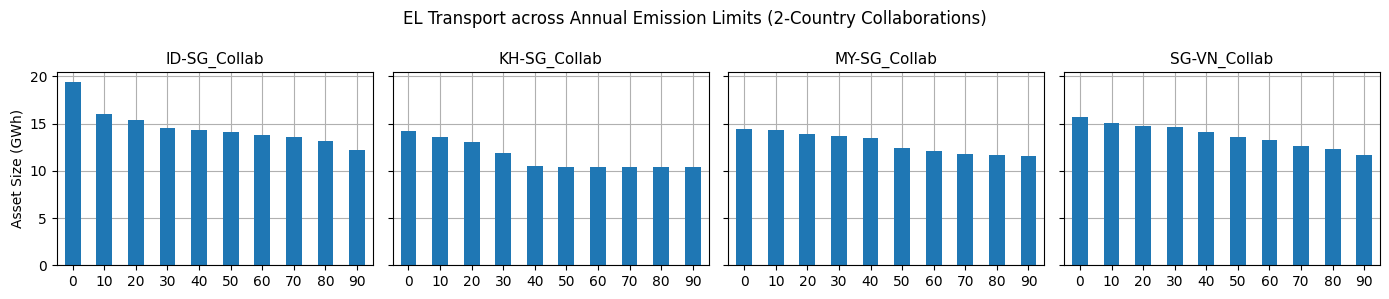

In [3]:
fig, ax = plt.subplots(1, 4, sharey=True, figsize=(14, 3))

cids = df.cid.unique().tolist()

for idx, cid in zip(range(5), cids):
    data = df.loc[df.cid==cid]
    data.plot(ax=ax[idx], kind="bar", x="sid", y="el_transport", rot=0, grid=True, legend=False)
    ax[idx].set_xlabel("")
    ax[idx].set_ylabel("Asset Size (GWh)")
    ax[idx].set_axisbelow(True)
    ax[idx].set_title(cid, fontsize=11)
plt.suptitle("EL Transport across Annual Emission Limits (2-Country Collaborations)")
plt.tight_layout()
plt.show();

In [4]:
df

,cid,sid,cost,emissions,el_transport
0,ID-SG_Collab,0,1795.434398,472.035675,19.460668
1,ID-SG_Collab,10,1626.764740,944.071340,16.028333
2,ID-SG_Collab,20,1535.413393,1420.000001,15.434225
3,ID-SG_Collab,30,1469.699873,1890.000000,14.492021
4,ID-SG_Collab,40,1431.637692,2220.000000,14.347277
5,ID-SG_Collab,50,1418.586518,2360.000000,14.078205
6,ID-SG_Collab,60,1382.230044,2830.000000,13.771069
7,ID-SG_Collab,70,1355.227604,3300.000000,13.581754
8,ID-SG_Collab,80,1334.731641,3780.000000,13.181876
9,ID-SG_Collab,90,1317.307251,4250.000000,12.188891
